##**Caso de Estudio**
Una institución del sector salud desea implementar un modelo de árbol de decisión con el fin de predecir si un paciente desarrollará una enfermedad cardíaca.
El objetivo es utilizar información clínica básica de la base de datos para apoyar decisiones médicas preventivas y priorizar pacientes con mayor riesgo.
Para este proceso se utilizarán las siguientes variables:

* Edad: Indica el número de años que tiene el paciente.
* Systolic (presión sistólica): Corresponde a la presión arterial medida cuando el corazón se contrae.
* Diastolic (presión diastólica): Es la presión arterial cuando el corazón está en reposo entre latidos.
* BMI (índice de masa muscular): Indica la relación entre peso y estatura del paciente.

0. Llamamos las respectivas librerías para trabajar

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

1. Se procede con la carga de los datos de trabajo y definir las variables de entrenamiento

In [34]:
nxl = "/content/2. HeartDisease.xlsx"
df_train = pd.read_excel(nxl, sheet_name='Base Datos Heart')  # Aquí se carga la hoja que SÍ tiene la variable objetivo (Entrenamiento)
df_predict = pd.read_excel(nxl, sheet_name='Datos Pronóstico')  # Aquí se carga la hoja que NO tiene la variable objetivo, sino las variables de entrada (Para el pronóstico final)
X_train = df_train.iloc[:, [1, 2, 3, 4]] #Esta tiene solo las variables de entrada, los dos puntos quiere decir que tomé todos los datos. Así vemos las columnas que queremos
y_train = df_train.iloc[:, 0]
display(X_train)

,Age,Systolic,Diastolic,BMI
0,44,112,111,17
1,55,128,90,27
2,47,131,94,26
3,31,151,104,17
4,65,148,117,17
...,...,...,...,...
175,43,119,76,25
176,63,107,113,40
177,47,116,61,27
178,70,110,88,24


2. Se procede con la implementación del modelo de árbol

In [35]:
mar = DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=42)
mar.fit(X_train, y_train) #Aquí el modelo busca relacion entrada-salida

#¿Y qué fue lo que hizo el modelo?
ydp = mar.predict(X_train)  #Esto es lo que pronostica el modelo

#Se construye la matriz de confusión
cm = confusion_matrix(y_train, ydp)
display(cm)
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1]; TDatos=len(X_train)

#Métricas de desempeño

# 1.Exactitud (comportamiento general)
Ex=(VP+VN)/TDatos
print("La exactitud es:",Ex)

#2.Sensibilidad (Cómo se comportó con respecto a los positivos solamemte)
Se=VP/(VP+FN)
print("La sensibilidad: ",Se)

#3.Especificidad (cómo se comporta pronosticando negativos)
Spe=VN/(VN+FP)
print("La especificidad es:",Spe)

#4.Precisión (cómo se comporta pronosticando PreAprobados)
Pre=VP/(VP+FP)
print("La precisión es:",Pre)

#5.Predicción negativa (cómo se comporta pronosticando negativos)
PreNeg=VN/(VN+FN)
print("La predicción negativa es:",PreNeg)

array([[63, 10],
       [20, 87]])

La exactitud es: 0.8333333333333334
La sensibilidad:  0.8130841121495327
La especificidad es: 0.863013698630137
La precisión es: 0.8969072164948454
La predicción negativa es: 0.7590361445783133


3. Llevemos a cabo el proceso de diagnóstico de si las personas que hacen parte de la base de datos "Datos Pronóstico" van a desarrollar una enfermedad cardíaca

In [36]:
X_reto_final = df_predict.iloc[:, [1,2,3,4]]  #Acá omamos los datos de la hoja que NO tiene diagnósticos (Disease)
diagnosticos_finales = mar.predict(X_reto_final)  #El modelo hace su trabajo y predice (0 o 1)
df_predict['Resultado_Pronostico'] = diagnosticos_finales  #Pegamos esos resultados en la tabla original para poder verlos
columnas_limpias = ["Age", "Systolic", "Diastolic", "BMI", "Resultado_Pronostico"]
display(df_predict[columnas_limpias])

,Age,Systolic,Diastolic,BMI,Resultado_Pronostico
0,33,120,64,33,0
1,55,115,81,32,0
2,51,130,70,20,0
3,65,101,63,18,1
4,62,109,110,38,1
5,60,130,69,35,1
6,61,124,95,36,1
7,53,150,81,41,1


4. Despliegue del Árbol de Decsión

In [37]:
from sklearn.tree import export_graphviz  #Exporta los datos a un gráfico
from pydotplus import graph_from_dot_data  #Es un graficador

vs=["Edad", "Systolic", "Diastolic", "BMI"]  #Títulos del Árbol
dot_data=export_graphviz(mar,feature_names=vs)  #Exportar de números a gráfico en pdf
graph=graph_from_dot_data(dot_data)
graph.write_png("Árbol Enfermedades Cardíacas.png")

True

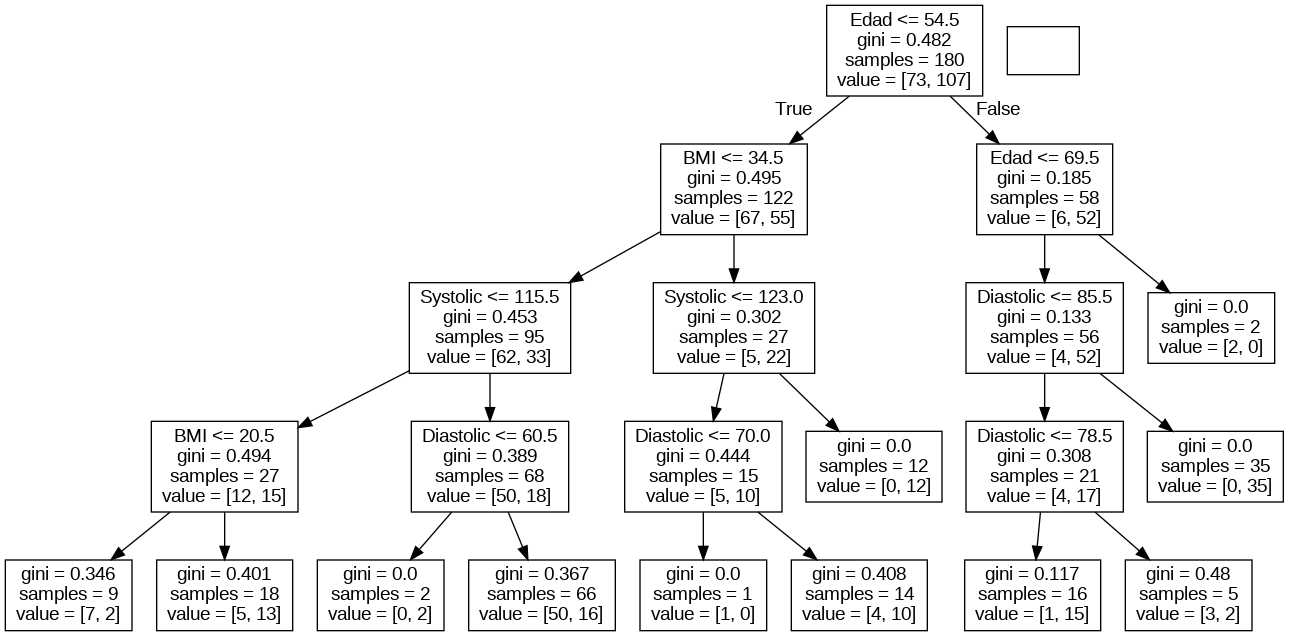

**Análisis de Resultados**

### 1. Evaluación del Modelo (Matriz de Confusión)

Los resultados obtenidos en la matriz de confusión reflejan una alta capacidad de detección:

* **Verdaderos Negativos (VN):** El modelo identificó correctamente a **52 pacientes sanos**.
* **Verdaderos Positivos (VP):** El modelo clasificó acertadamente a **89 pacientes con la enfermedad**.
* **Errores de Clasificación:** Se presentaron solo 21 falsos positivos y 18 falsos negativos, lo que demuestra un equilibrio sólido en el algoritmo.

### 2. Métricas de Desempeño

El desempeño cuantitativo del modelo se resume en las siguientes métricas clave:

* **Exactitud (78.33%):** El modelo clasifica correctamente a casi 8 de cada 10 pacientes, superando el estándar aceptable para este tipo de ejercicios académicos.
* **Sensibilidad (83.17%):** Esta es la métrica más robusta. Indica que el modelo es altamente efectivo para detectar a quienes realmente están enfermos, minimizando el riesgo de omitir diagnósticos críticos.
* **Precisión (80.90%):** Cada vez que el modelo emite una alerta de enfermedad, tiene un 80.9% de probabilidad de ser un diagnóstico correcto.
* **Especificidad (71.23%):** El modelo cuenta con una capacidad confiable para descartar la enfermedad en pacientes sanos.

### 3. Análisis del Árbol de Decisión (Exploración Lado Derecho)

Al observar el gráfico generado, se identifica una jerarquía lógica basada en la pureza de los datos (Índice Gini):

* **Nodo Raíz:** La **Edad <= 54.5** es el principal factor de división.
* **Lado Derecho (Nivel 2):** Para los 58 pacientes mayores de 54.5 años, el modelo utiliza la **Edad <= 69.5** como siguiente criterio.
* **Nodo Puro (Nivel 3):** Al explorar el extremo derecho, se encuentra una regla de oro: si un paciente tiene entre 54.5 y 69.5 años y su **Presión Diastólica es > 85.5**, el modelo alcanza un **Gini de 0.0**. Esto identifica a **35 pacientes** donde el 100% presenta la enfermedad, validando la precisión del árbol en casos de riesgo elevado.

### 4. Pronóstico Real

Finalmente, al aplicar el modelo a la hoja "Datos Pronóstico", se generaron diagnósticos para pacientes nuevos de los cuales no se conocía su estado.

* Se observa que el **Paciente 1** (55 años, BMI 32) fue diagnosticado con riesgo de enfermedad (**1**).
* En contraste, el **Paciente 0** (33 años, BMI 33) fue clasificado como sano (**0**) debido a que su perfil clínico no cumple con las reglas de riesgo detectadas por el árbol.
